In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import preprocess_maps

# returns N_H2, N_H2_OA, N_H2_OB, wcs, wcs_OA, wcs_OB (preprocessed maps)
N_H2, N_H2_OA, N_H2_OB, wcs, wcs_OA, wcs_OB = preprocess_maps.derive_density_maps()

# returns M_H2_OA, M_H2_OB (mass maps)
M_H2_OA = preprocess_maps.convert_to_mass(N_H2_OA)
M_H2_OB = preprocess_maps.convert_to_mass(N_H2_OB)

Using: /home/simone/Documents/Astronomy/Paper Fractal ISM/01_code/Fractal_Star_Formation/inputs/Lombardi_maps/planck_herschel.fits.gz


/home/simone/Documents/Astronomy/Paper Fractal ISM/01_code/Fractal_Star_Formation/src/plot_tools.py:95: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label("Column Density Threshold [$\mathrm{cm}^{-2}$]", fontsize=15)
/home/simone/Documents/Astronomy/Paper Fractal ISM/01_code/Fractal_Star_Formation/src/plot_tools.py:487: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Column Density Threshold [$\mathrm{cm}^{-2}$]', fontsize=13)
/home/simone/Documents/Astronomy/Paper Fractal ISM/01_code/Fractal_Star_Formation/src/plot_tools.py:509: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Column Density Threshold [$\mathrm{cm}^{-2}$]", fontsize=18)


Correlation coefficient: 0.9883
Slope: 1.4689 ± 0.0229
Fractal dimension D = 1.36 ± 0.02
Average residual (very symmentrical): -0.0000
Mean absolute residual: 0.1180


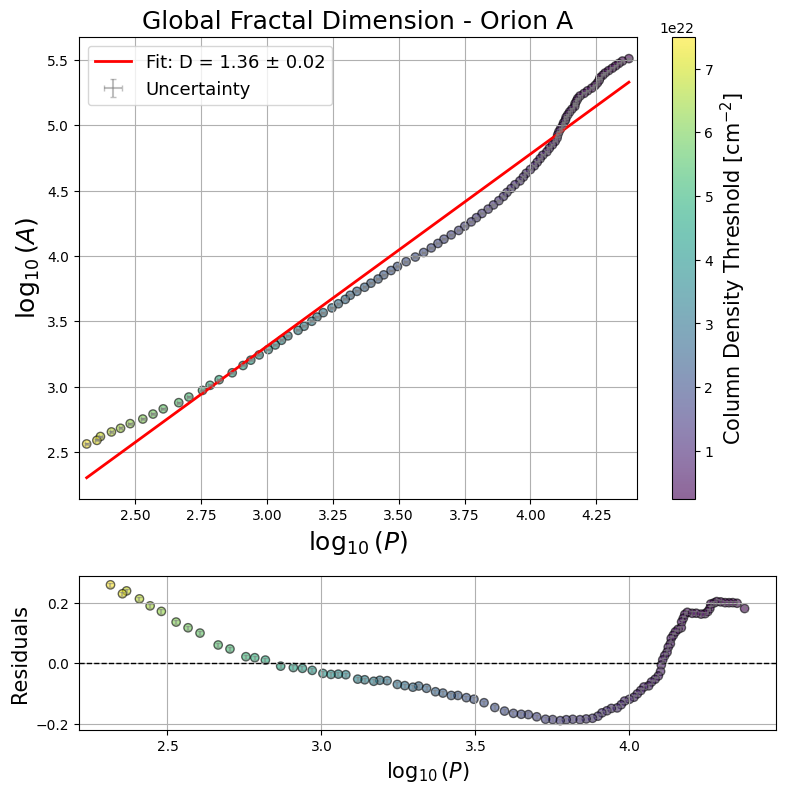

In [2]:
from src import minkowski_functionals, plot_tools
import numpy as np

# Orion A
name_region = "Orion A"

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 7.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down
# threshold_max = 1.0e23

# Minkowski
results_OA = minkowski_functionals.compute_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)
plot_tools.plot_global_fractal_dimension(results=results_OA, threshold_min=threshold_min, threshold_max=threshold_max, name_region=name_region)

fractal_dimension_OA = results_OA["fractal_dimension"]

#TODO: double fit, errors etc.. (Global Properties)

Keeping 98 points between 2.50e+21 and 7.50e+22
Low range points : 53
High range points: 45

Low log(P) <= 3.9
  slope = 1.2176 ± 0.0086
  D = 1.64 ± 0.01
  corr = 0.9987

High log(P) > 3.9
  slope = 2.5243 ± 0.0460
  D = 0.79 ± 0.01
  corr = 0.9929

Residuals summary (Low range)
Mean residual: -8.6304e-16
Mean absolute residual: 0.0202
RMS residual: 0.0277
Std deviation: 0.0277

Residuals summary (High range)
Mean residual: -5.4080e-15
Mean absolute residual: 0.0286
RMS residual: 0.0348
Std deviation: 0.0348


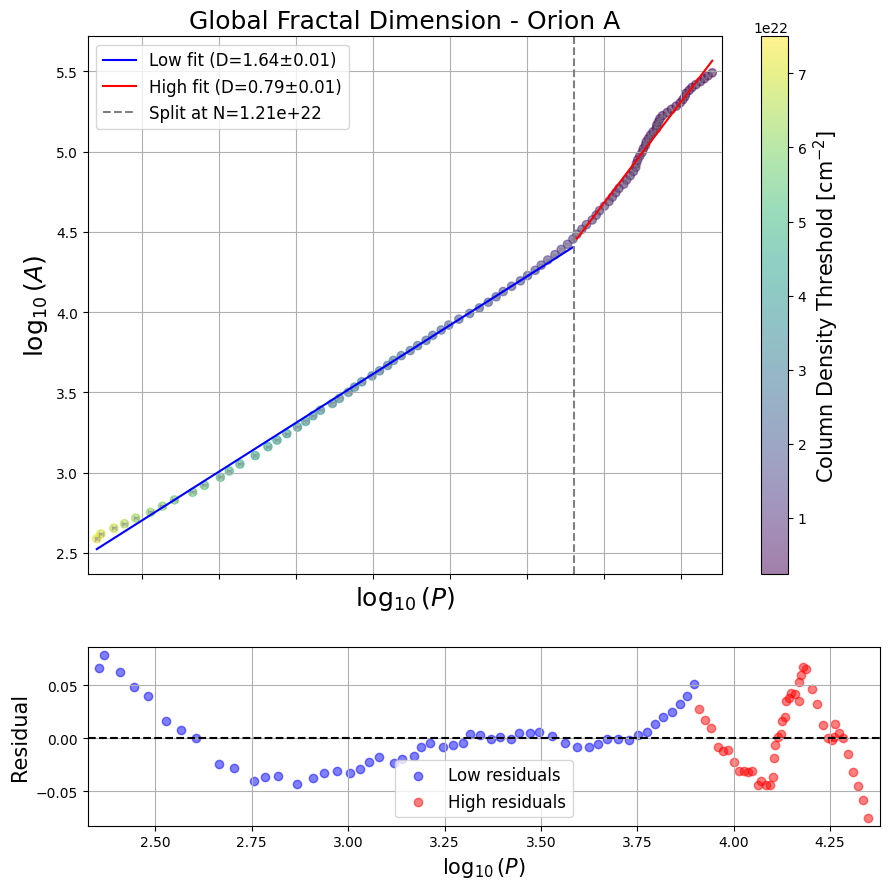

{'low': {'slope': np.float64(1.2176124669240445),
  'intercept': np.float64(-0.34207154610600976),
  'slope_err': np.float64(0.008564257249316245),
  'D': np.float64(1.6425587404278454),
  'D_err': np.float64(0.011553179671093547),
  'corr': np.float64(0.9987408410857236),
  'residuals': array([ 0.05096134,  0.03970925,  0.03239569,  0.02489608,  0.02019371,
          0.01362575,  0.00564064,  0.00297661, -0.00185905, -0.00094518,
         -0.00054163, -0.00526366, -0.0086091 , -0.0084467 , -0.00455795,
          0.00240203,  0.00568214,  0.00464478,  0.00499856, -0.00038195,
          0.00060019, -0.00110392,  0.00297371,  0.00403376, -0.0045723 ,
         -0.00603693, -0.00816823, -0.00422521, -0.00880808, -0.01704519,
         -0.01948779, -0.02307685, -0.01824065, -0.02242472, -0.02932126,
         -0.0326386 , -0.03135565, -0.03264498, -0.037474  , -0.04319898,
         -0.03570357, -0.03653081, -0.04049214, -0.02802813, -0.02455257,
         -0.00016027,  0.00755053,  0.0165631 ,

In [3]:
name_region = "Orion A"

# # Threshold range, test these
threshold_min = 2.5e21
threshold_max = 7.5e22

plot_tools.plot_global_fractal_dimension_double_fit(
    results=results_OA, 
    threshold_min=threshold_min, 
    threshold_max=threshold_max, split_value=3.9, name_region=name_region
    )

Correlation coefficient: 0.9976
Slope: 1.4301 ± 0.0101
Fractal dimension D = 1.40 ± 0.01
Average residual (very symmentrical): -0.0000
Mean absolute residual: 0.0494


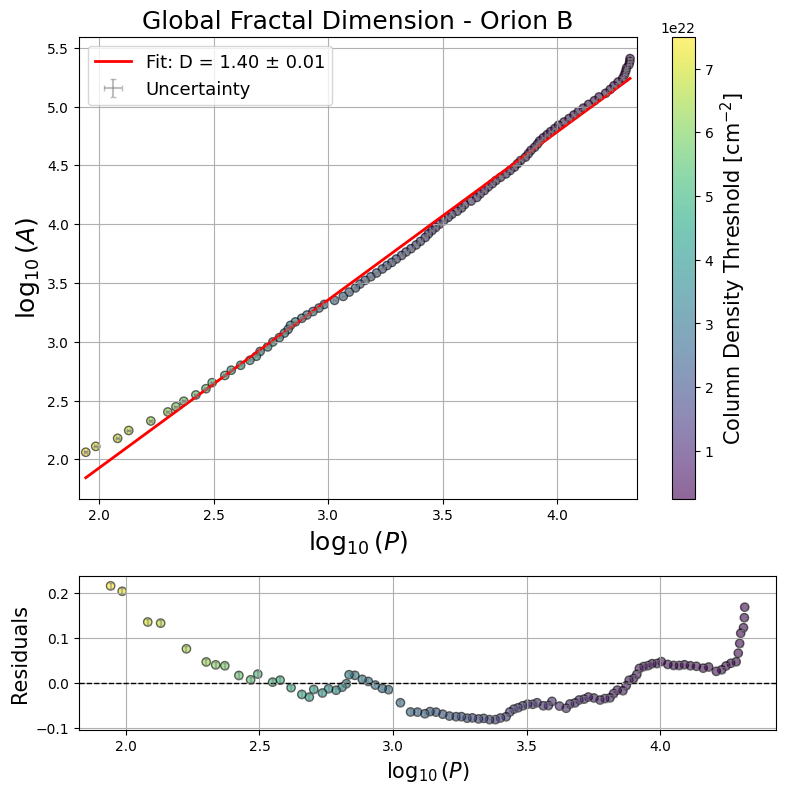

In [4]:
# Orion B
name_region = "Orion B"

# Minkowski
results_OB = minkowski_functionals.compute_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)
plot_tools.plot_global_fractal_dimension(results=results_OB, threshold_min=threshold_min, threshold_max=threshold_max, name_region=name_region)

fractal_dimension_OB = results_OB["fractal_dimension"]

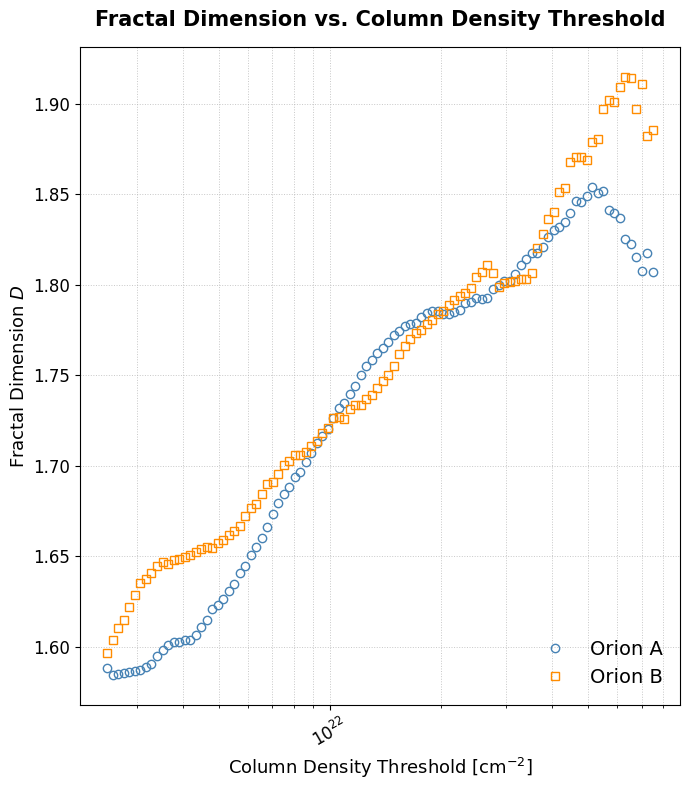

In [5]:
plot_tools.plot_global_fractal_dimension_together(results_OA=results_OA, results_OB=results_OB, errors=False)